In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
#Cas n°1 : Ici l'économie se déroule dans un environnement libre et stable, les agents sont rationnels, l'information est parfaite et il n'y a pas d'impact ni d'influence d'acteurs exterieurs (état etc..)
#il n'y a donc pas non plus de régulation ni d'intervention étatique et ni de bulles speculatives

In [307]:
def passage(matrice, etat):
    """ en fontion d'un état, cette fonction définit aléatoirement le prochain état du marché """
    nvetat = 0
    k = np.random.uniform()
    if k <matrice[etat][0]:
        nvetat =0
    else:
        if k < matrice[etat][0] + matrice[etat][1] and k >= matrice[etat][0]:   
            nvetat = 1
        else:
            nvetat = 2
    return nvetat

#on definit etat 0 = crise, etat 1 = stable, etat 2 = croissance


def probapopulation(etat, vecteurpopulation):
    """Fonction qui modifie l'opinion de la population en fonction de l'état du marché"""
    vecteur = []
    if etat == 0:
        return vecteurpopulation * 0.8
    if etat == 1:
        return vecteurpopulation
    if etat == 2: 
        for e in vecteurpopulation:
            if e*1.2<1:
               vecteur.append(e*1.2)
            else:
                vecteur.append(1)
        return np.array(vecteur)


def prop_investisseurs(etat, vecteurpopulation):
    """fonction qui determine le nombre d'investisseurs en fonction de l'état du marché"""
    if etat == 2:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.4])
    if etat == 1:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.5])
    if etat == 0:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.6])
    
    return vecteur_investisseurs



def calculer_indice(vecteurindice, vecteur_investisseurs, etat, liste):
    """fonction qui calcule l'indice global du marché en fonction de l'état du marché et du nombre d'investisseurs"""
    res = 0
    for i in range(len(vecteurindice)):
        res = 0
        if etat == 0:
            for inv in vecteur_investisseurs:
                res = res - np.random.normal(0.1, 0.000001)          #on simplifie, tous les prix diminuent lors d'une crise
            # print(res)
            vecteurindice[i] += res

        if etat == 2:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0.05, 0.0005)
            vecteurindice[i] += res

        if etat == 1:
            for inv in vecteur_investisseurs:
                res = res + np.random.normal(0, 0.00001)
            vecteurindice[i] += res
    
    nv_indice = np.mean(vecteurindice) 
    liste.append(nv_indice)
    return nv_indice



def probamatrice(matrice,etat, indice1, indice0, epsilon): 
    """fonction qui permet de modifier la probabilité de la matrice de transition en fonction de la variation de l'indice global des prix"""
    variation = (indice1 -indice0)/indice0
    sensibilité = epsilon

    if variation > 0:
        transfert = min(matrice[etat][0], abs(sensibilité*variation))
        matrice[etat][0] -= transfert 
        matrice[etat][2] += transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]
    
    if variation < 0:
        transfert = min(matrice[etat][2], abs(sensibilité*variation))
        matrice[etat][0] += transfert
        matrice[etat][2] -= transfert
        matrice[etat][1] = 1 - matrice[etat][0] - matrice[etat][2]     

    return matrice


In [308]:

def fonction_cas1(matrice, etat, vecteurpopulation, vecteurindice, n, epsilon):
    nvetat = 0
    vecteur_indices = [1]
    matrice_pop = []
    vecteur_etats = [etat]
    res = 0
    max = -1
    for i in range(n):
        nvetat = passage(matrice, etat)

        vecteurpopulation = probapopulation(nvetat, vecteurpopulation)
        matrice_pop.append(vecteurpopulation.copy())

        vecteur_investisseurs = prop_investisseurs(nvetat, vecteurpopulation)

        nouvel_indice = calculer_indice(vecteurindice, vecteur_investisseurs, nvetat, vecteur_indices)

        matrice = probamatrice(matrice, nvetat, vecteur_indices[i], vecteur_indices[i+1],epsilon)

        vecteur_etats.append(nvetat)
        
        if nvetat == etat:
            res += 1
        else:
            res = 1 
            
        if res > max:
            max = res

    return matrice, vecteur_etats, vecteur_investisseurs, vecteur_indices, matrice_pop, max

    

In [309]:
#variables exogènes

indice0 = 1
population = 1000
titres = 25
res = [indice0]
matrice = [[0.9, 0.05, 0.05], [0.05, 0.9, 0.05], [0.05, 0.05, 0.9]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

#ce que les gens investissent

vecteurpopulation1 = np.random.normal(0.5, 0.15, population) 
# vecteur contenant toutes les opinions de la population, aux extremes on a des gens qui investissent beaucoup ou peu les valeurs sont comprises entre 0 et 1

vecteurindice1 = np.array([np.random.uniform()*10 for _ in range(titres)])
#vecteur contenant tous les indices de prix  l'indice positif veut dire que les prix ont globalement augmenté, l'indice négatif veut dire que les prix ont globalement diminué
#les prix sont tirés aléatoirement entre 0 et 10 le choix de l'encadrement est arbitraire, on peut le changer


In [310]:
indice0 = 1
population = 10
titres2 = 10
res = [indice0]
matrice = [[0.9, 0.1 ,0], [0.05,0.9,0.05], [0,0.1,0.9]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation3 = np.random.normal(0.5, 0.15, population) 
vecteurindices3 = np.array([np.random.uniform()*2 for _ in range(titres2)])

watf3 = fonction_cas1(matrice=matrice, etat= 2, vecteurpopulation = vecteurpopulation3, vecteurindice=vecteurindices3, n=20, epsilon =0.01)


In [311]:
indice0 = 1
population = 10
titres2 = 10
res = [indice0]
matrice = [[0.9, 0.1 ,0], [0.05,0.9,0.05], [0,0.1,0.9]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation2 = np.random.normal(0.5, 0.15, population) 
vecteurindices2 = np.array([np.random.uniform()*1 for _ in range(titres2)])

watf2 = fonction_cas1(matrice=matrice, etat= 1, vecteurpopulation = vecteurpopulation2, vecteurindice=vecteurindices2, n=20, epsilon =0.01)

In [312]:
indice0 = 1
population = 10
titres2 = 10
res = [indice0]
matrice = [[0.9, 0.1 ,0], [0.05,0.9,0.05], [0,0.1,0.9]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation1 = np.random.normal(0.5, 0.15, population) 
vecteurindices1 = np.array([np.random.uniform()*(-1) for _ in range(titres2)])
vecteurindices1
watf1 = fonction_cas1(matrice=matrice, etat= 0, vecteurpopulation = vecteurpopulation1, vecteurindice=vecteurindices1, n=20, epsilon =0.01)

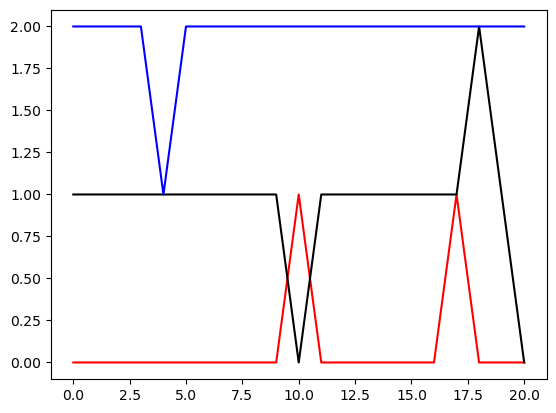

In [313]:
abscisse = np.arange(0, len(watf[1]), 1)
plt.plot(abscisse, watf1[1], color = 'red')
plt.plot(abscisse, watf2[1], c ='black')
plt.plot(abscisse, watf3[1], c ='blue')

In [314]:
watf1[3]


[1,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731,
 -0.5195276058659731]

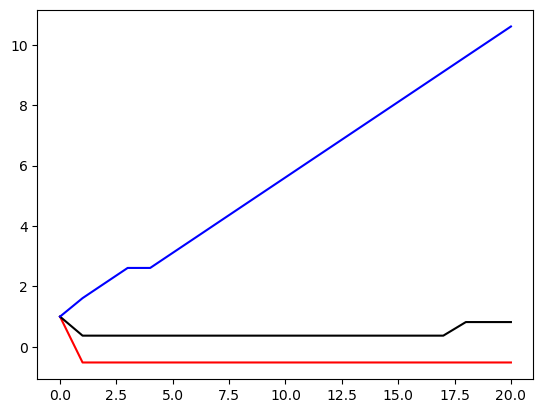

In [315]:
grapheindice= np.arange(0, len(watf[3]), 1)
plt.plot(grapheindice, watf1[3], color = 'red')
plt.plot(grapheindice, watf2[3], c ='black')
plt.plot(grapheindice, watf3[3], c ='blue')


In [325]:
indice0 = 1
population = 10
titres2 = 10
res = [indice0]
matrice = [[0.55, 0.15 ,0.3], [0.45,0.35,0.2], [0.40,0.1,0.5]]  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation4 = np.random.normal(0.5, 0.15, population) 
vecteurindices4 = np.array([np.random.uniform() for _ in range(titres2)])

watf4 = fonction_cas1(matrice=matrice, etat= 2, vecteurpopulation = vecteurpopulation4, vecteurindice=vecteurindices4, n=20, epsilon =0.01)


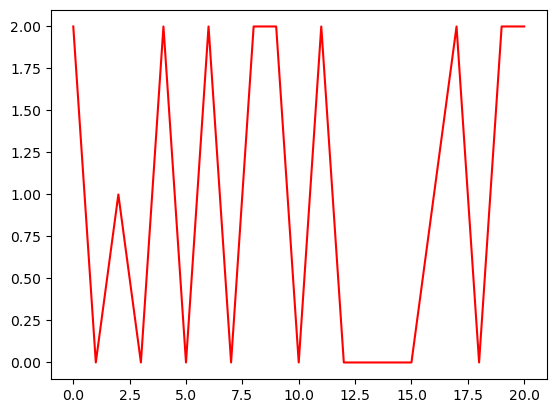

In [326]:
abscisse = np.arange(0, len(watf4[1]), 1)
plt.plot(abscisse, watf1[1], color = 'red')


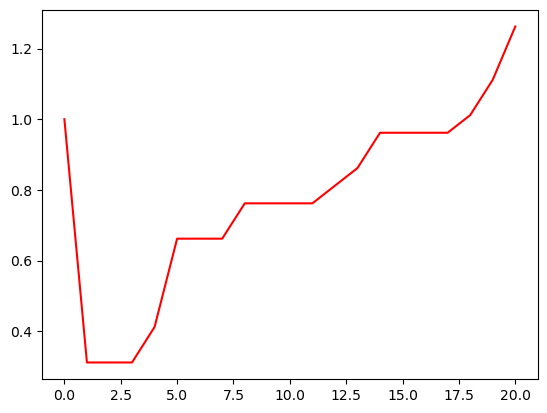

In [328]:
grapheindice= np.arange(0, len(watf4[3]), 1)
plt.plot(grapheindice, watf4[3], color = 'red')

